# 🇻🇳 Transfer Learning — N-BEATS v3 → Vietnam Fine-tuning

**Chiến lược:** Load pretrained N-BEATS (đa quốc gia) → Fine-tune trên dữ liệu Việt Nam.

---

### Điểm khác biệt N-BEATS so với TFT trong Transfer Learning:

| Thông số | TFT | N-BEATS |
|---|---|---|
| Input | Target + covariates (weather, econ...) | Chỉ target history (univariate) |
| Transfer strategy | Freeze LSTM + Attention (Phase 1) | Copy FC block weights → Fine-tune toàn bộ |
| Economic features | Dùng làm unknown_reals | Không dùng (N-BEATS thuần TS) |
| Interpretability | Variable importance, attention | Trend/Seasonality decomposition |

### Chiến lược Fine-tuning N-BEATS:
```
Phase 1 (Epoch 1-15) : Copy pretrained weights → Fine-tune với LR = 1e-3  
Phase 2 (Epoch 16+)  : Tiếp tục với LR = 1e-4 (giảm để ổn định trên dataset nhỏ)
```

> **Lưu ý:** N-BEATS là univariate model nên không cần match feature columns giữa source/target dataset như TFT.  
> Việc copy weights hoàn toàn feasible vì kiến trúc giống nhau.

In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 1 — IMPORTS & PATHS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import warnings, os, json, shutil, copy
from pathlib import Path
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import lightning.pytorch as pl
from lightning.pytorch.callbacks import (
    EarlyStopping, ModelCheckpoint, LearningRateMonitor
)
from lightning.pytorch.loggers import TensorBoardLogger

from pytorch_forecasting import TimeSeriesDataSet, NBeats
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import SMAPE

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}',
      f'({torch.cuda.get_device_name(0)})' if DEVICE == 'cuda' else '')

BASE_DIR       = Path(r'.')
VN_DATA_PATH   = BASE_DIR / 'data' / 'processed' / 'VN_data' / 'vn_tft_ready.csv'
PRETRAIN_CKPT  = BASE_DIR / 'checkpoint' / 'nbeats_v3_best.ckpt'
CKPT_DIR       = BASE_DIR / 'checkpoint'
LOG_DIR        = BASE_DIR / 'lightning_logs' / 'nbeats_vn_v3'
LOG_DIR.mkdir(parents=True, exist_ok=True)

print(f'VN data : {VN_DATA_PATH}')
print(f'Pretrain: {PRETRAIN_CKPT}')
print(f'Exists  : {PRETRAIN_CKPT.exists()}')

PyTorch : 2.5.1+cu121
Device  : cuda (NVIDIA GeForce RTX 3050 Ti Laptop GPU)
VN data : data\processed\VN_data\vn_tft_ready.csv
Pretrain: checkpoint\nbeats_v3_best.ckpt
Exists  : True


In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 2 — HYPERPARAMETERS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CFG = dict(
    # Dataset
    max_encoder_length    = 18,
    max_prediction_length = 6,
    min_series_length     = 24,
    val_cutoff_months     = 12,

    # N-BEATS architecture (phải khớp với pretraining notebook)
    stack_types                   = ["trend", "seasonality"],
    num_blocks                    = [3, 3],
    num_block_layers              = [4, 4],
    widths                        = [256, 256],
    expansion_coefficient_lengths = [3, 7],
    dropout                       = 0.1,

    # Phase 1
    phase1_lr             = 1e-3,
    phase1_epochs         = 20,
    phase1_patience       = 7,

    # Phase 2
    phase2_lr             = 1e-4,
    phase2_epochs         = 40,
    phase2_patience       = 10,

    # Training
    batch_size            = 32,
    gradient_clip_val     = 0.1,
    num_workers           = 0,
    seed                  = 42,
)

pl.seed_everything(CFG['seed'], workers=True)
print('Config N-BEATS VN Transfer Learning:')
for k, v in CFG.items():
    print(f'  {k:<32}: {v}')

Seed set to 42


Config N-BEATS VN Transfer Learning:
  max_encoder_length              : 18
  max_prediction_length           : 6
  min_series_length               : 24
  val_cutoff_months               : 12
  stack_types                     : ['trend', 'seasonality']
  num_blocks                      : [3, 3]
  num_block_layers                : [4, 4]
  widths                          : [256, 256]
  expansion_coefficient_lengths   : [3, 7]
  dropout                         : 0.1
  phase1_lr                       : 0.001
  phase1_epochs                   : 20
  phase1_patience                 : 7
  phase2_lr                       : 0.0001
  phase2_epochs                   : 40
  phase2_patience                 : 10
  batch_size                      : 32
  gradient_clip_val               : 0.1
  num_workers                     : 0
  seed                            : 42


In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3 — LOAD & CHUẨN BỊ DATA VN
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
df = pd.read_csv(VN_DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
print(f'Raw VN shape: {df.shape}')
print(f'Series      : {sorted(df["series"].unique())}')

# ── Loại Other fossil (73% zeros — không học được) ────────────────────────────
FINE_TUNE_SERIES = ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind']
df = df[df['series'].isin(FINE_TUNE_SERIES)].copy()
print(f'After filter: {df.shape} — Series: {sorted(df["series"].unique())}')

# ── Đảm bảo time_idx liên tục ─────────────────────────────────────────────────
df = df.sort_values(['entity', 'series', 'date'])
df['time_idx'] = df.groupby(['entity','series'])['date'].rank(method='dense').astype(int) - 1

# ── Xử lý NaN ─────────────────────────────────────────────────────────────────
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df.groupby(['entity', 'series'])[num_cols].transform(
    lambda x: x.interpolate(method='linear').bfill().ffill()
)

nan_counts = df.isnull().sum()
print(f'Total NaN after clean: {nan_counts.sum()}')
print(f'Date range: {df["date"].min().date()} -> {df["date"].max().date()}')
print()
print('Serie lengths:')
for s, g in df.groupby('series'):
    print(f'  {s}: {len(g)} months, time_idx=[{g["time_idx"].min()},{g["time_idx"].max()}]')

Raw VN shape: (432, 30)
Series      : ['Coal', 'Gas', 'Hydro', 'Other fossil', 'Solar', 'Wind']
After filter: (360, 30) — Series: ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind']
Total NaN after clean: 0
Date range: 2019-01-01 -> 2024-12-01

Serie lengths:
  Coal: 72 months, time_idx=[0,71]
  Gas: 72 months, time_idx=[0,71]
  Hydro: 72 months, time_idx=[0,71]
  Solar: 72 months, time_idx=[0,71]
  Wind: 72 months, time_idx=[0,71]


In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 4 — TimeSeriesDataSet cho N-BEATS VN
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
training_cutoff = int(df['time_idx'].max()) - CFG['val_cutoff_months']
val_cutoff_date = df['date'].max() - pd.DateOffset(months=CFG['val_cutoff_months'])
print(f'Training cutoff time_idx: {training_cutoff} (date ~ {val_cutoff_date.date()})')
print(f'Train/Val rows: {(df["time_idx"]<=training_cutoff).sum()} / {(df["time_idx"]>training_cutoff).sum()}')

print('\nCreating TimeSeriesDataSet for N-BEATS...')
training_vn = TimeSeriesDataSet(
    df[df['time_idx'] <= training_cutoff],
    time_idx='time_idx',
    target='generation_TWh',
    group_ids=['entity', 'series'],
    min_encoder_length=CFG['max_encoder_length'],
    max_encoder_length=CFG['max_encoder_length'],
    min_prediction_length=CFG['max_prediction_length'],
    max_prediction_length=CFG['max_prediction_length'],
    static_categoricals=[],
    static_reals=[],
    time_varying_known_categoricals=[],
    time_varying_known_reals=[],
    time_varying_unknown_categoricals=[],
    time_varying_unknown_reals=['generation_TWh'],
    target_normalizer=GroupNormalizer(
        groups=['entity', 'series'],
        transformation='softplus',
    ),
    add_relative_time_idx=False,
    add_target_scales=False,
    add_encoder_length=False,
    allow_missing_timesteps=True,
    randomize_length=None,
)

validation_vn = TimeSeriesDataSet.from_dataset(
    training_vn, df, predict=True, stop_randomization=True
)
print(f'Training samples  : {len(training_vn):,}')
print(f'Validation samples: {len(validation_vn):,}')

Training cutoff time_idx: 59 (date ~ 2023-12-01)
Train/Val rows: 300 / 60

Creating TimeSeriesDataSet for N-BEATS...
Training samples  : 185
Validation samples: 5


In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 5 — DATALOADERS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
train_loader = training_vn.to_dataloader(
    train=True, batch_size=CFG['batch_size'], num_workers=CFG['num_workers']
)
val_loader = validation_vn.to_dataloader(
    train=False, batch_size=CFG['batch_size'] * 4, num_workers=CFG['num_workers']
)

x, y = next(iter(train_loader))
print('DataLoaders OK')
print(f'  Encoder : {x["encoder_cont"].shape}')
print(f'  Target  : {y[0].shape}')
print(f'  Train batches: {len(train_loader)}')

DataLoaders OK
  Encoder : torch.Size([32, 18, 1])
  Target  : torch.Size([32, 6])
  Train batches: 5


In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 — TẠO MODEL N-BEATS VN & COPY PRETRAINED WEIGHTS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
vn_model = NBeats.from_dataset(
    training_vn,
    stack_types=CFG['stack_types'],
    num_blocks=CFG['num_blocks'],
    num_block_layers=CFG['num_block_layers'],
    widths=CFG['widths'],
    expansion_coefficient_lengths=CFG['expansion_coefficient_lengths'],
    dropout=CFG['dropout'],
    loss=SMAPE(),
    learning_rate=CFG['phase1_lr'],
    optimizer='adam',
    log_interval=5,
)

n_params_vn = sum(p.numel() for p in vn_model.parameters() if p.requires_grad)
print(f'VN model parameters: {n_params_vn:,} ({n_params_vn/1e6:.2f}M)')

if PRETRAIN_CKPT.exists():
    pretrained_ckpt = torch.load(str(PRETRAIN_CKPT), map_location='cpu')
    pretrained_state = pretrained_ckpt['state_dict']

    vn_state = vn_model.state_dict()
    transferred, skipped = [], []

    for name, param in pretrained_state.items():
        if name in vn_state:
            if vn_state[name].shape == param.shape:
                vn_state[name].copy_(param)
                transferred.append(name)
            else:
                skipped.append(f'{name}: shape {param.shape} -> {vn_state[name].shape}')
        else:
            skipped.append(f'{name}: not in VN model')

    vn_model.load_state_dict(vn_state)
    print(f'\n✅ Transferred weights : {len(transferred)}')
    print(f'   Skipped (shape diff): {len(skipped)}')
    if skipped:
        print('  Sample skipped:', skipped[:5])
    total_items = len(transferred) + len(skipped)
    if total_items > 0:
        print(f'\n   Transfer rate: {len(transferred) / total_items * 100:.1f}%')
else:
    print(f'⚠️  Pretrained checkpoint not found: {PRETRAIN_CKPT}')
    print('   Training từ đầu (scratch)...')

VN model parameters: 1,220,352 (1.22M)

✅ Transferred weights : 60
   Skipped (shape diff): 12
  Sample skipped: ['net_blocks.0.T_backcast: shape torch.Size([3, 24]) -> torch.Size([3, 18])', 'net_blocks.0.fc.0.weight: shape torch.Size([256, 24]) -> torch.Size([256, 18])', 'net_blocks.1.T_backcast: shape torch.Size([3, 24]) -> torch.Size([3, 18])', 'net_blocks.1.fc.0.weight: shape torch.Size([256, 24]) -> torch.Size([256, 18])', 'net_blocks.2.T_backcast: shape torch.Size([3, 24]) -> torch.Size([3, 18])']

   Transfer rate: 83.3%


In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 7 — PHASE 1: FINE-TUNE VỚI LR = 1e-3
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# N-BEATS không có LSTM/Attention để freeze như TFT.
# Chiến lược: Phase 1 dùng LR cao hơn để adapt nhanh → Phase 2 LR nhỏ để tinh chỉnh.
# Toàn bộ model đều được train trong cả 2 phase.

print('Phase 1 — Full fine-tune với LR cao:')
trainable_params = sum(p.numel() for p in vn_model.parameters() if p.requires_grad)
print(f'  Trainable params: {trainable_params:,} (100%)')

vn_model.hparams.learning_rate = CFG['phase1_lr']

ckpt_p1 = ModelCheckpoint(
    dirpath=str(CKPT_DIR), filename='nbeats_vn_phase1_{epoch:02d}_{val_loss:.4f}',
    monitor='val_loss', mode='min', save_top_k=1, save_last=False
)
es_p1 = EarlyStopping(
    monitor='val_loss', patience=CFG['phase1_patience'], mode='min', verbose=True
)

trainer_p1 = pl.Trainer(
    accelerator         = 'gpu' if DEVICE == 'cuda' else 'cpu',
    devices             = 1,
    max_epochs          = CFG['phase1_epochs'],
    gradient_clip_val   = CFG['gradient_clip_val'],
    callbacks           = [ckpt_p1, es_p1],
    logger              = TensorBoardLogger(str(BASE_DIR / 'lightning_logs'), name='nbeats_vn_phase1'),
    enable_progress_bar = True,
    precision           = '32',
)

print(f'\nPhase 1 Training: LR={CFG["phase1_lr"]}, epochs={CFG["phase1_epochs"]}, patience={CFG["phase1_patience"]}')
print('=' * 60)

trainer_p1.fit(vn_model, train_dataloaders=train_loader, val_dataloaders=val_loader)

print(f'\nPhase 1 done! Best val_loss = {ckpt_p1.best_model_score:.6f}')

Phase 1 — Full fine-tune với LR cao:
  Trainable params: 1,220,352 (100%)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 3050 Ti Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision



Phase 1 Training: LR=0.001, epochs=20, patience=7


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss            │ SMAPE      │      0 │ train │     0 │
│ 1 │ logging_metrics │ ModuleList │      0 │ train │     0 │
│ 2 │ net_blocks      │ ModuleList │  1.2 M │ train │     0 │
└───┴─────────────────┴────────────┴────────┴───────┴───────┘

...

Metric val_loss improved by 0.004 >= min_delta = 0.0. New best score: 0.264


Metric val_loss improved by 0.002 >= min_delta = 0.0. New best score: 0.263


Metric val_loss improved by 0.002 >= min_delta = 0.0. New best score: 0.261


`Trainer.fit` stopped: `max_epochs=20` reached.



Phase 1 done! Best val_loss = 0.260724


In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 8 — PHASE 2: FINE-TUNE VỚI LR NHỎ HƠN
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Load best Phase 1 → tiếp tục với LR nhỏ
best_p1_path = ckpt_p1.best_model_path
vn_model_p2  = NBeats.load_from_checkpoint(best_p1_path)

trainable_p2 = sum(p.numel() for p in vn_model_p2.parameters() if p.requires_grad)
print(f'Phase 2 — Full fine-tune với LR nhỏ:')
print(f'  Trainable params: {trainable_p2:,} (100%)')

vn_model_p2.hparams.learning_rate = CFG['phase2_lr']

ckpt_p2 = ModelCheckpoint(
    dirpath  = str(CKPT_DIR),
    filename = 'nbeats_vn_v3_{epoch:02d}_{val_loss:.4f}',
    monitor  = 'val_loss',
    mode     = 'min',
    save_top_k = 3,
    save_last  = True,
    verbose    = True,
)
es_p2 = EarlyStopping(
    monitor='val_loss', patience=CFG['phase2_patience'], mode='min', verbose=True
)
lr_monitor = LearningRateMonitor(logging_interval='epoch')

trainer_p2 = pl.Trainer(
    accelerator         = 'gpu' if DEVICE == 'cuda' else 'cpu',
    devices             = 1,
    max_epochs          = CFG['phase2_epochs'],
    gradient_clip_val   = CFG['gradient_clip_val'],
    callbacks           = [ckpt_p2, es_p2, lr_monitor],
    logger              = TensorBoardLogger(str(BASE_DIR / 'lightning_logs'), name='nbeats_vn_phase2'),
    enable_progress_bar = True,
    precision           = '32',
)

print(f'\nPhase 2 Training: LR={CFG["phase2_lr"]}, epochs={CFG["phase2_epochs"]}, patience={CFG["phase2_patience"]}')
print('=' * 60)

trainer_p2.fit(vn_model_p2, train_dataloaders=train_loader, val_dataloaders=val_loader)

print(f'\nPhase 2 done! Best val_loss = {ckpt_p2.best_model_score:.6f}')
print(f'Best checkpoint  : {ckpt_p2.best_model_path}')

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Phase 2 — Full fine-tune với LR nhỏ:
  Trainable params: 1,220,352 (100%)

Phase 2 Training: LR=0.0001, epochs=40, patience=10


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss            │ SMAPE      │      0 │ train │     0 │
│ 1 │ logging_metrics │ ModuleList │      0 │ train │     0 │
│ 2 │ net_blocks      │ ModuleList │  1.2 M │ train │     0 │
└───┴─────────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 1.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.2 M                                                                                                
Total estimated model params size (MB): 4                                                                          
Modules in train mode: 110                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Epoch 16, global step 85: 'val_loss' was not in top 3


Epoch 17, global step 90: 'val_loss' was not in top 3


Epoch 18, global step 95: 'val_loss' was not in top 3


Monitored metric val_loss did not improve in the last 10 records. Best score: 0.254. Signaling Trainer to stop.
Epoch 19, global step 100: 'val_loss' was not in top 3



Phase 2 done! Best val_loss = 0.253975
Best checkpoint  : C:\Users\ADMIN\OneDrive - Hanoi University of Mining and Geology\Documents\NCKH\TFT-GreenPower-Forecasting\checkpoint\nbeats_vn_v3_epoch=09_val_loss=0.2540-v1.ckpt


In [10]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 9 — LƯU CHECKPOINT CUỐI
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FINAL_CKPT   = CKPT_DIR / 'nbeats_vn_v3_best.ckpt'
FINAL_LATEST = CKPT_DIR / 'nbeats_vn_v3_latest.ckpt'

if os.path.exists(ckpt_p2.best_model_path):
    shutil.copy2(ckpt_p2.best_model_path, FINAL_CKPT)
    print(f'Best  -> {FINAL_CKPT}')
if os.path.exists(ckpt_p2.last_model_path):
    shutil.copy2(ckpt_p2.last_model_path, FINAL_LATEST)
    print(f'Latest-> {FINAL_LATEST}')

vn_config = {
    'version'                : 'nbeats_vn_v3',
    'pretrained_from'        : str(PRETRAIN_CKPT),
    'best_ckpt'              : str(FINAL_CKPT),
    'best_val_loss'          : float(ckpt_p2.best_model_score),
    'phase1_val_loss'        : float(ckpt_p1.best_model_score),
    'fine_tune_series'       : FINE_TUNE_SERIES,
    'max_encoder_length'     : CFG['max_encoder_length'],
    'max_prediction_length'  : CFG['max_prediction_length'],
    'target'                 : 'generation_TWh',
    'group_ids'              : ['entity', 'series'],
    'target_normalizer'      : 'GroupNormalizer(softplus)',
    'stack_types'            : CFG['stack_types'],
    'num_blocks'             : CFG['num_blocks'],
    'num_block_layers'       : CFG['num_block_layers'],
    'widths'                 : CFG['widths'],
    'expansion_coefficient_lengths': CFG['expansion_coefficient_lengths'],
    'phase1_lr'              : CFG['phase1_lr'],
    'phase2_lr'              : CFG['phase2_lr'],
    'model_type'             : 'NBeats (univariate)',
    'note'                   : 'No covariates - pure target history forecasting',
}

cfg_path = CKPT_DIR / 'nbeats_vn_v3_config.json'
with open(cfg_path, 'w', encoding='utf-8') as f:
    json.dump(vn_config, f, indent=2, ensure_ascii=False)
print(f'Config -> {cfg_path}')

Best  -> checkpoint\nbeats_vn_v3_best.ckpt
Latest-> checkpoint\nbeats_vn_v3_latest.ckpt
Config -> checkpoint\nbeats_vn_v3_config.json


In [11]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 10 — EVALUATION: METRICS TỔNG QUÁT
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
best_vn = NBeats.load_from_checkpoint(str(FINAL_CKPT))
best_vn.eval()
print(f'Loaded: {FINAL_CKPT.name}')

raw_preds   = best_vn.predict(val_loader, mode='raw', return_x=True)
point_preds = best_vn.predict(val_loader, mode='prediction', return_x=True)
pred_vals, x_vals = point_preds.output, point_preds.x

actuals = torch.cat([y[0] for _, y in val_loader])

mae   = (actuals - pred_vals).abs().mean().item()
rmse  = ((actuals - pred_vals) ** 2).mean().sqrt().item()
smape_val = (2*(actuals - pred_vals).abs() /
             (actuals.abs() + pred_vals.abs() + 1e-8)).mean().item() * 100
wape  = ((actuals - pred_vals).abs().sum() /
         (actuals.abs().sum() + 1e-8)).item() * 100
ss_res = ((actuals - pred_vals) ** 2).sum().item()
ss_tot = ((actuals - actuals.mean()) ** 2).sum().item()
r2 = 1.0 - (ss_res / (ss_tot + 1e-8))

print(f'\nValidation Metrics — N-BEATS VN Fine-tuned (2024):')
print(f'  MAE   : {mae:.4f} TWh')
print(f'  RMSE  : {rmse:.4f} TWh')
print(f'  R2    : {r2:.4f}')
print(f'  SMAPE : {smape_val:.2f}%')
print(f'  WAPE  : {wape:.2f}%')

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelC

Loaded: nbeats_vn_v3_best.ckpt

Validation Metrics — N-BEATS VN Fine-tuned (2024):
  MAE   : 1.2340 TWh
  RMSE  : 1.8478 TWh
  R2    : 0.8401
  SMAPE : 25.40%
  WAPE  : 23.12%


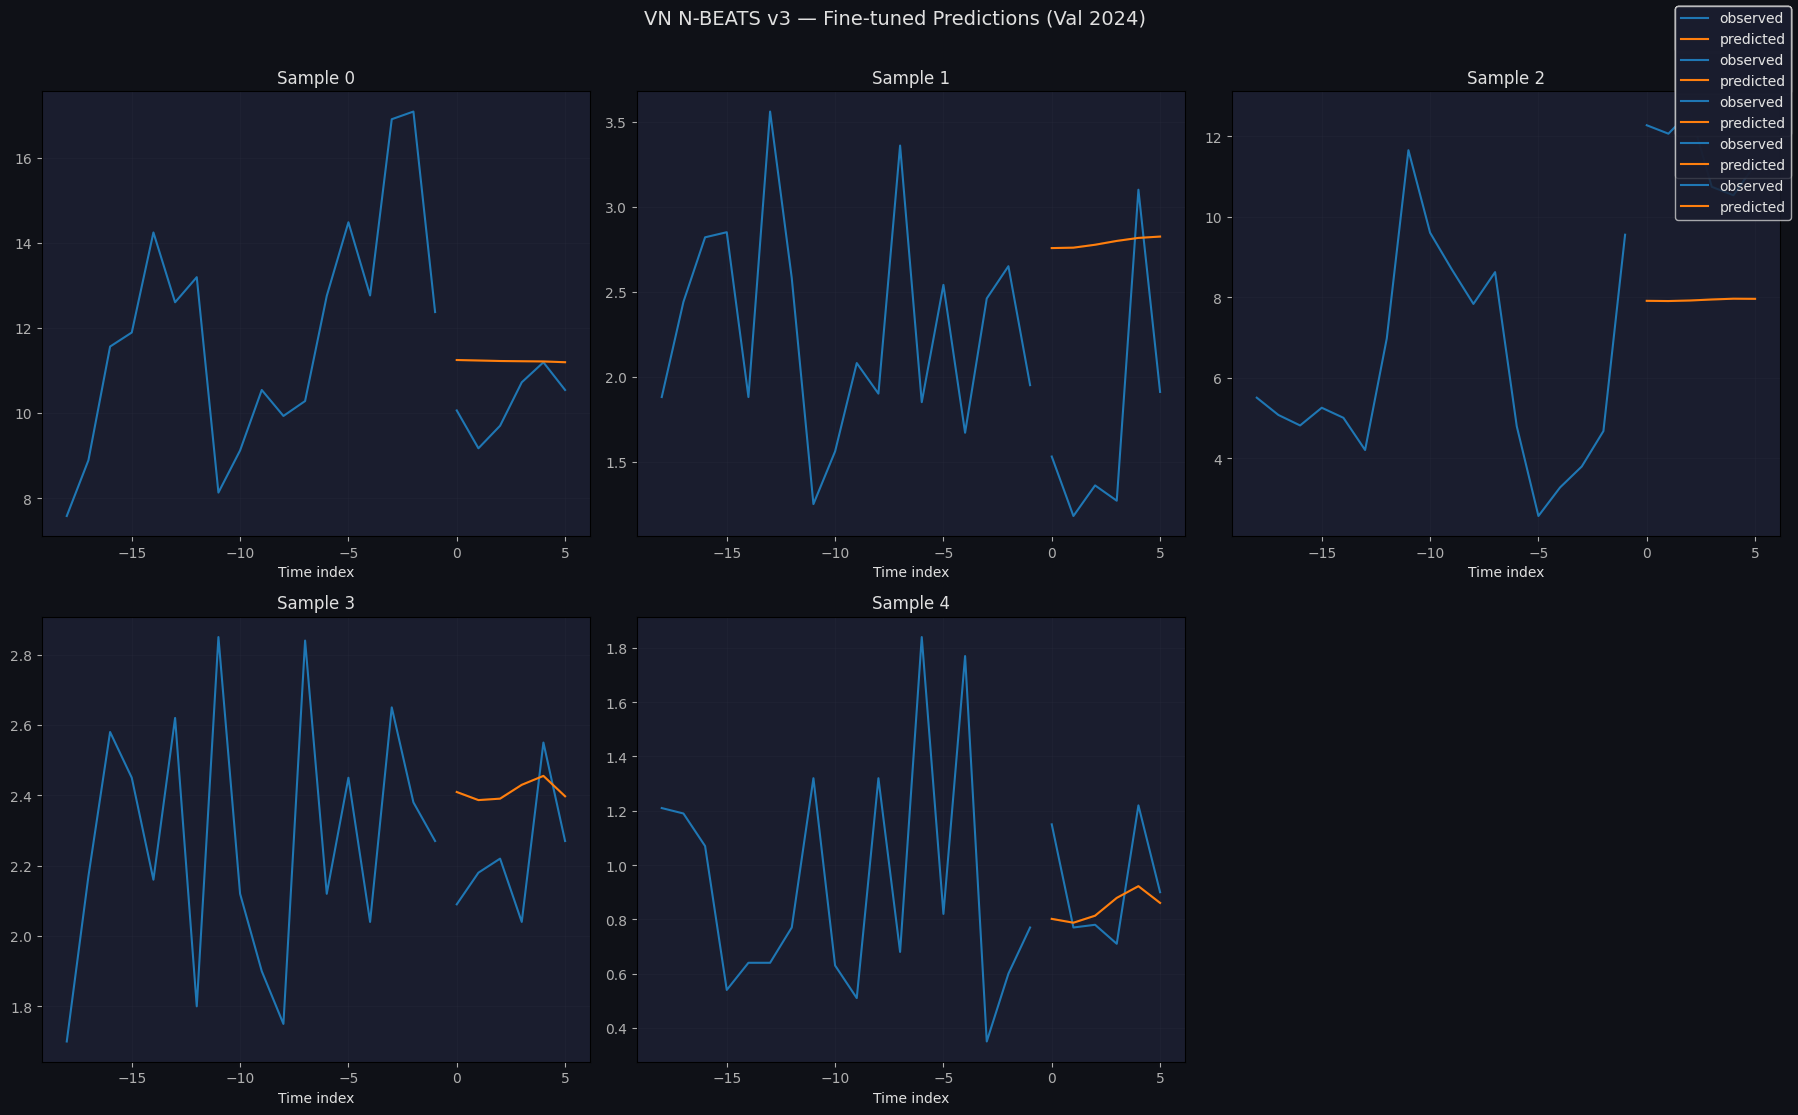

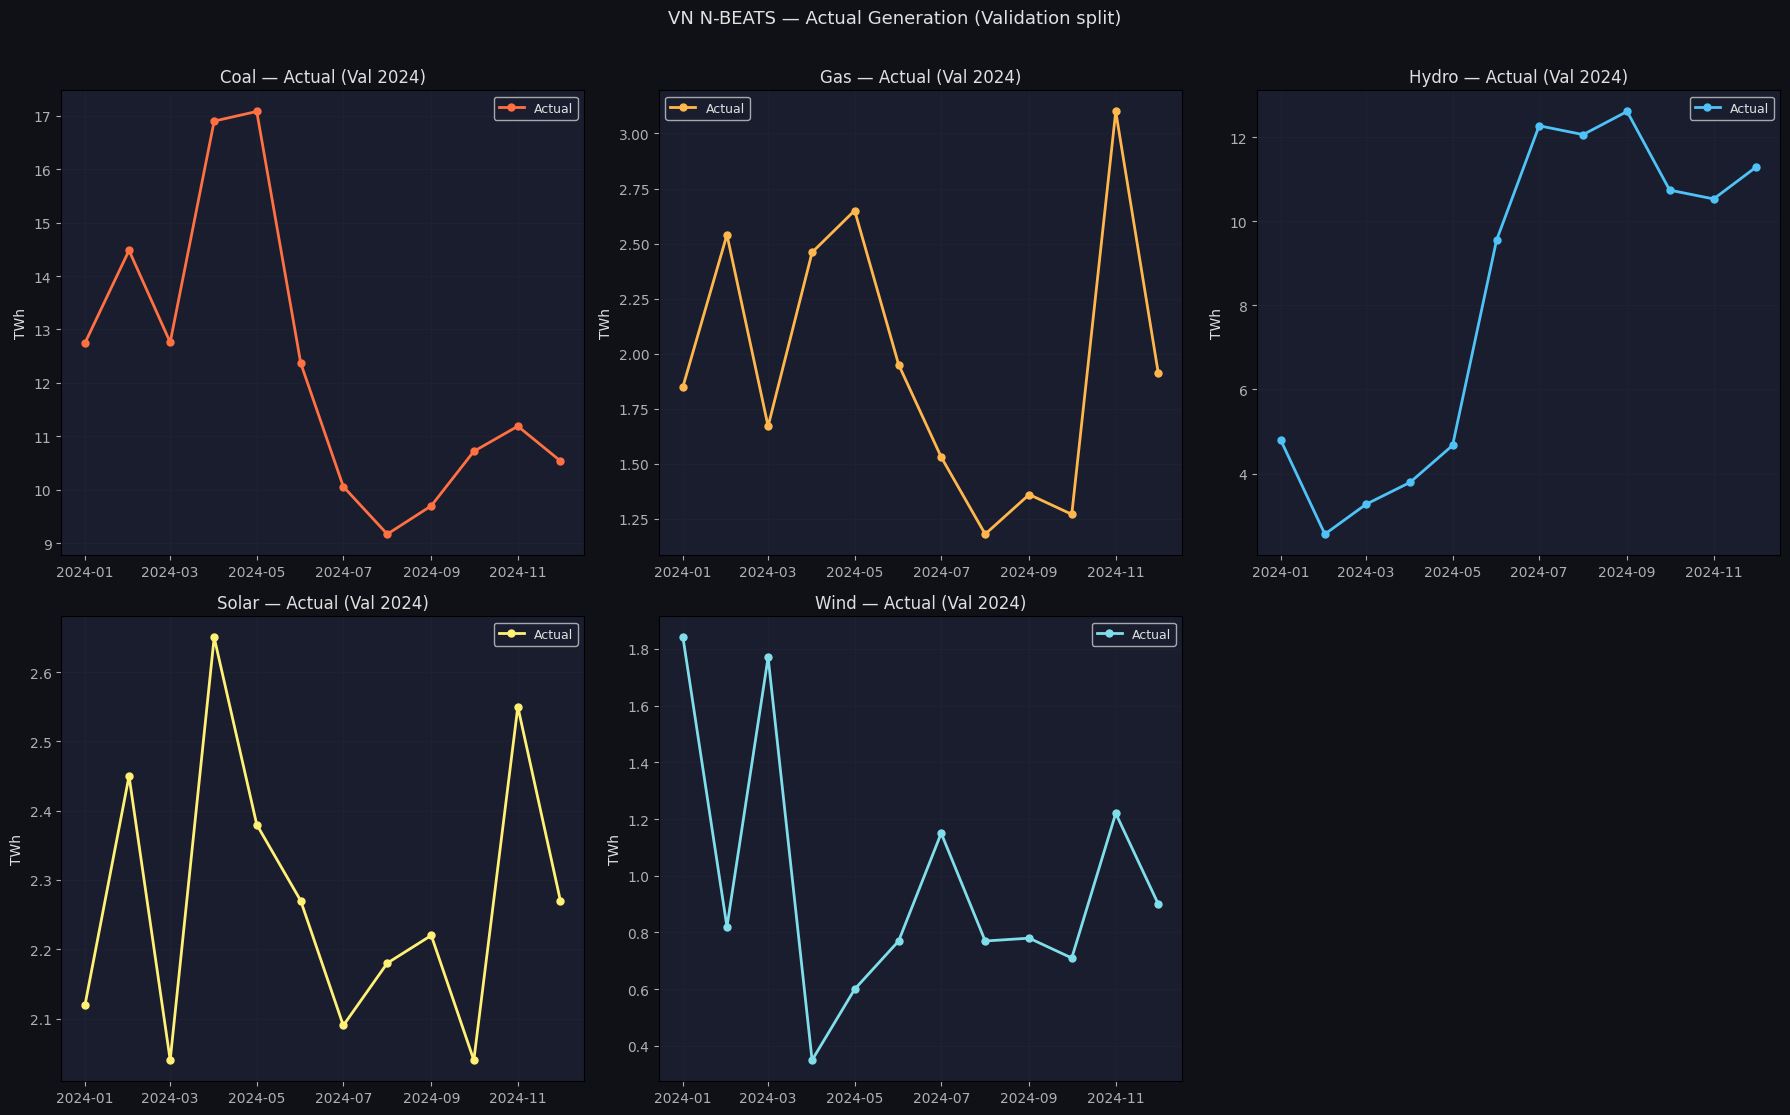

In [12]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 11 — VISUALIZE PREDICTIONS PER SERIES
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d2e',
    'text.color': '#e0e0e0', 'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#b0b0b0', 'ytick.color': '#b0b0b0',
    'grid.color': '#2a2d3e', 'grid.alpha': 0.5,
})

SERIES_COLORS = {
    'Coal': '#ff7043', 'Gas': '#ffb74d', 'Hydro': '#4fc3f7',
    'Solar': '#fff176', 'Wind': '#80deea',
}

# Plot prediction samples
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for i, ax in enumerate(axes.flatten()):
    try:
        best_vn.plot_prediction(raw_preds.x, raw_preds.output, idx=i, ax=ax)
        ax.set_title(f'Sample {i}')
        ax.grid(alpha=0.3)
    except Exception:
        ax.set_visible(False)

plt.suptitle('VN N-BEATS v3 — Fine-tuned Predictions (Val 2024)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Actual vs Predicted per series
df_val = df[df['time_idx'] > training_cutoff].copy()
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, ser in enumerate(FINE_TUNE_SERIES):
    ax = axes[i]
    sub = df_val[df_val['series'] == ser].sort_values('date')
    color = SERIES_COLORS.get(ser, '#aaa')
    ax.plot(sub['date'], sub['generation_TWh'], 'o-', color=color,
            linewidth=2, markersize=5, label='Actual')
    ax.set_title(f'{ser} — Actual (Val 2024)')
    ax.set_ylabel('TWh')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

axes[5].set_visible(False)
plt.suptitle('VN N-BEATS — Actual Generation (Validation split)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 12 — N-BEATS DECOMPOSITION (Trend + Seasonality)
# Đây là điểm mạnh của N-BEATS: diễn giải được trend/seasonality
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
try:
    # N-BEATS trong pytorch-forecasting hỗ trợ plot_interpretation
    interpretation = best_vn.interpret_output(
        raw_preds.output, reduction='sum'
    )
    if interpretation:
        figs = best_vn.plot_interpretation(interpretation)
        for title, fig in figs.items():
            if hasattr(fig, 'suptitle'):
                fig.suptitle(f'VN N-BEATS — {title}', fontsize=12)
                plt.tight_layout()
                plt.show()
except Exception as e:
    print(f'Note: Decomposition visualization không có với generic N-BEATS: {e}')
    print('      Chỉ dùng được với N-BEATS-I (interpretable stacks: trend + seasonality)')

Note: Decomposition visualization không có với generic N-BEATS: 'NBeats' object has no attribute 'interpret_output'
      Chỉ dùng được với N-BEATS-I (interpretable stacks: trend + seasonality)


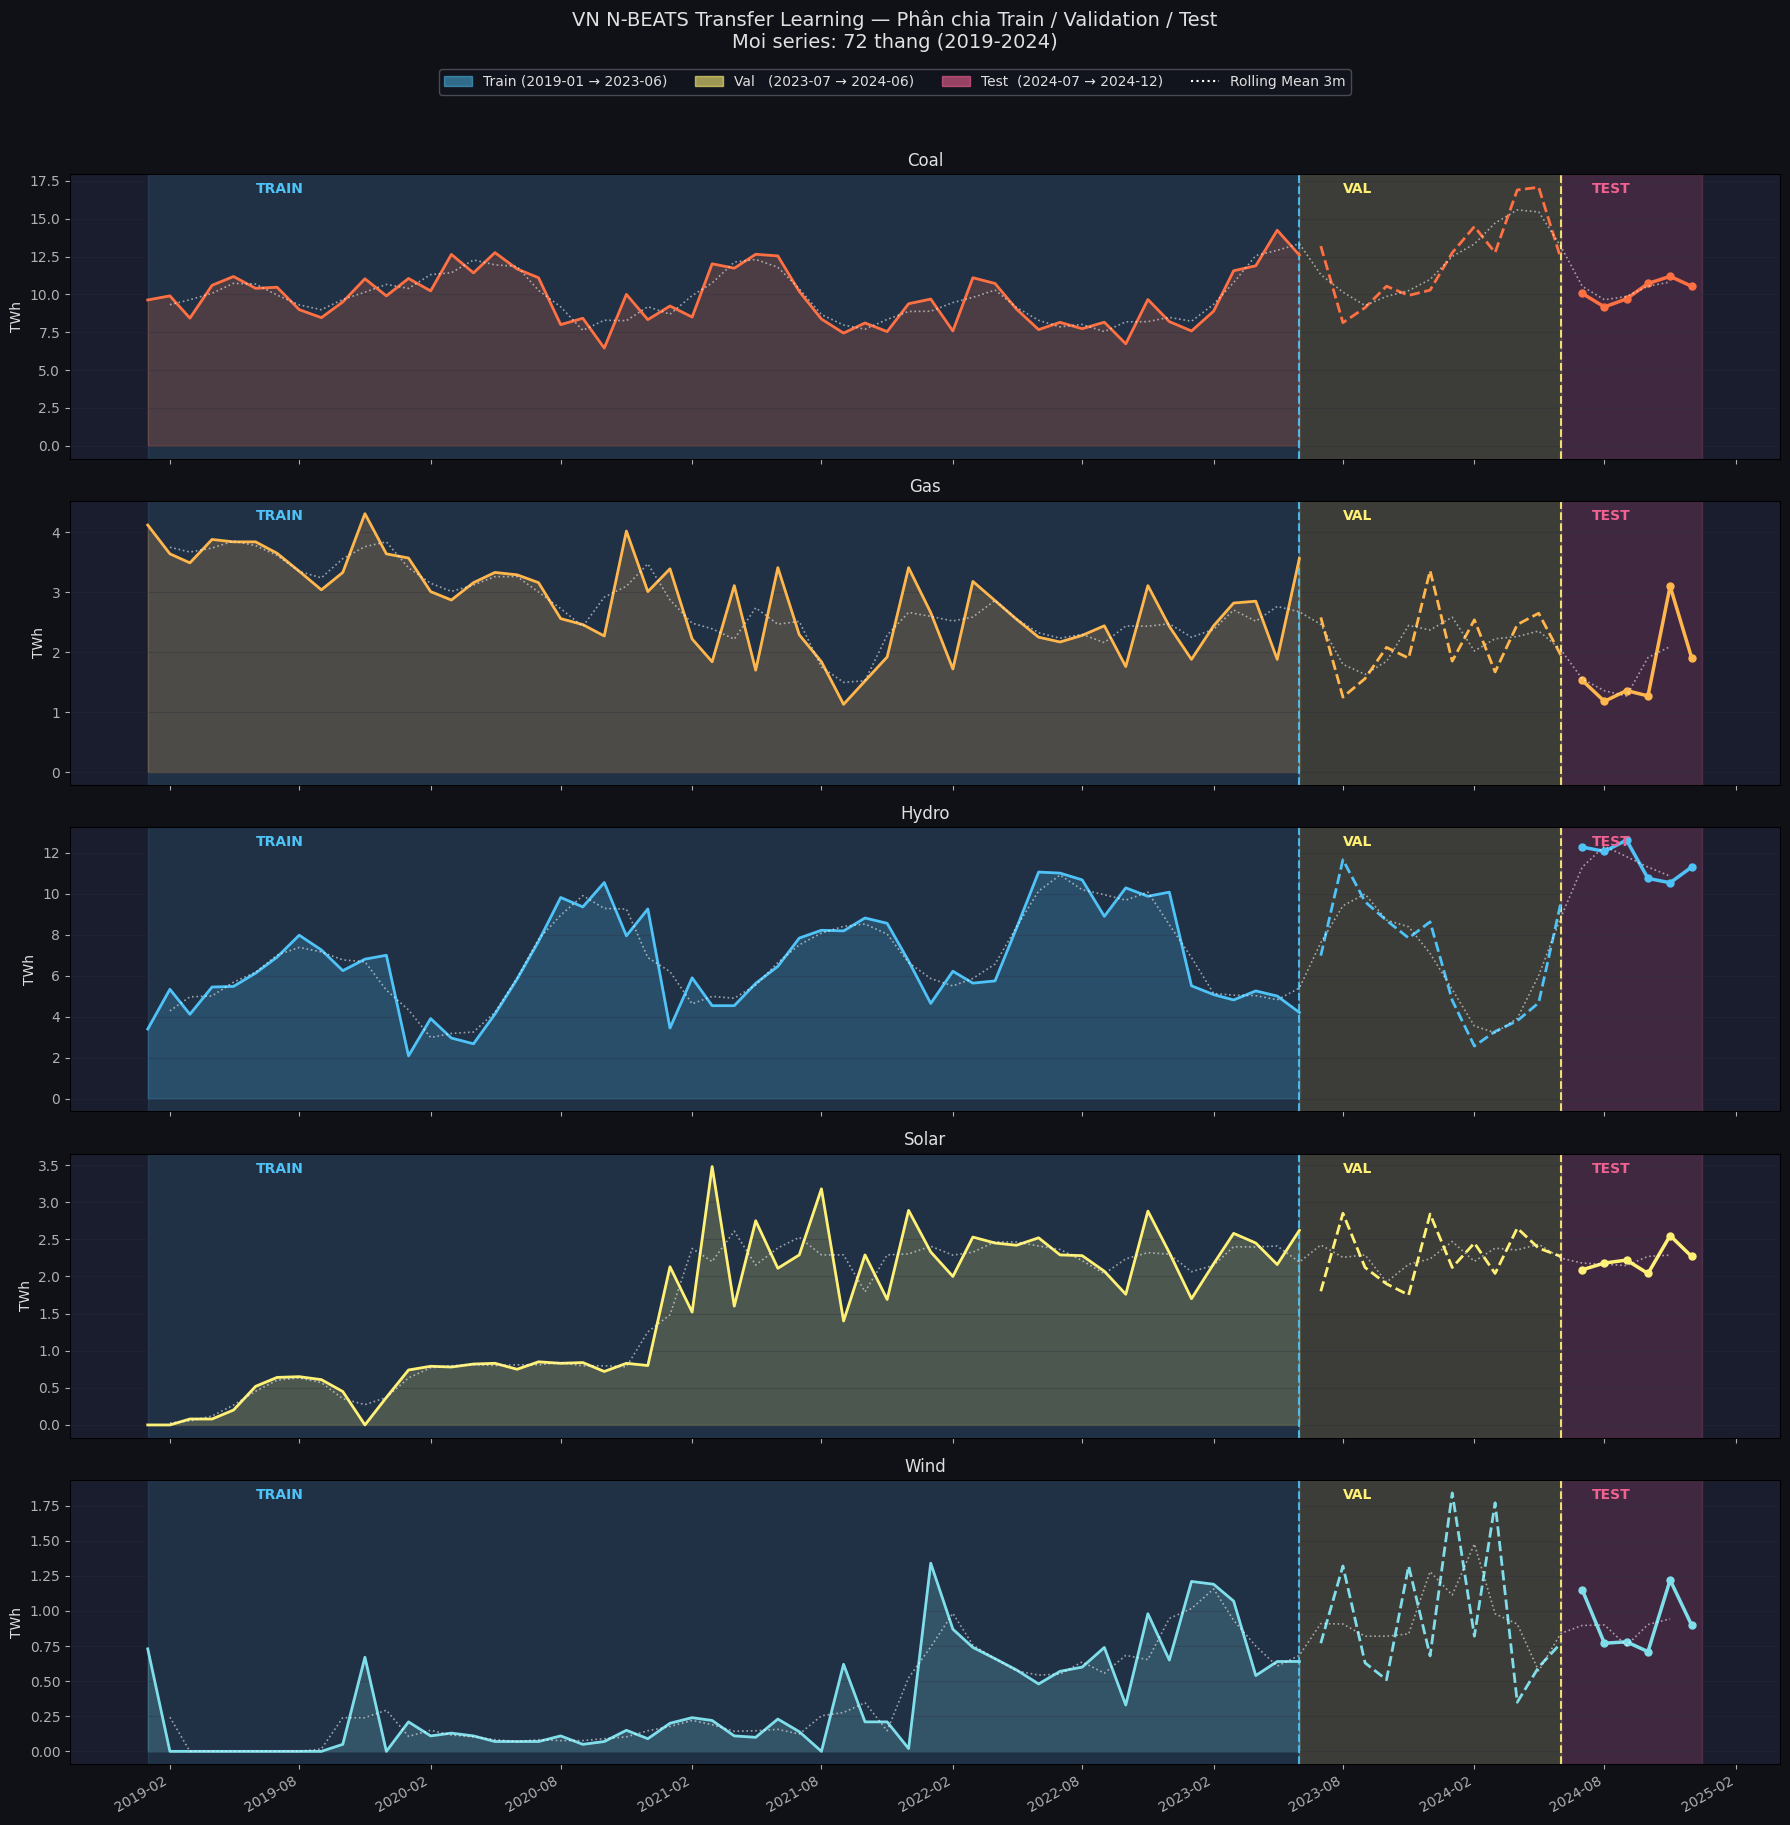


Bang tom tat so lieu moi split:
Split    Tu           Den           Thang
------------------------------------------
Train    2019-01-01   2023-06-01       54
Val      2023-07-01   2024-06-01       12
Test     2024-07-01   2024-12-01        6


In [14]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 13 — TỔNG QUAN: TRAIN / VAL / TEST SPLIT VISUALIZATION
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TRAIN_END = pd.Timestamp('2023-06-01')
VAL_END   = pd.Timestamp('2024-06-01')
TEST_END  = df['date'].max()

fig, axes = plt.subplots(len(FINE_TUNE_SERIES), 1,
                         figsize=(18, 3.5 * len(FINE_TUNE_SERIES)),
                         sharex=True)

for ax, ser in zip(axes, FINE_TUNE_SERIES):
    sub   = df[df['series'] == ser].sort_values('date')
    color = SERIES_COLORS.get(ser, '#aaa')

    ax.axvspan(sub['date'].min(), TRAIN_END, alpha=0.12, color='#4fc3f7', label='_nolegend_')
    ax.axvspan(TRAIN_END, VAL_END, alpha=0.15, color='#fff176', label='_nolegend_')
    ax.axvspan(VAL_END, TEST_END + pd.DateOffset(days=15), alpha=0.18, color='#f06292', label='_nolegend_')

    ax.axvline(TRAIN_END, color='#4fc3f7', linewidth=1.5, linestyle='--', alpha=0.9)
    ax.axvline(VAL_END,   color='#fff176', linewidth=1.5, linestyle='--', alpha=0.9)

    train_sub = sub[sub['date'] <= TRAIN_END]
    ax.plot(train_sub['date'], train_sub['generation_TWh'], color=color, linewidth=2.0)
    ax.fill_between(train_sub['date'], train_sub['generation_TWh'], alpha=0.2, color=color)

    val_sub = sub[(sub['date'] > TRAIN_END) & (sub['date'] <= VAL_END)]
    ax.plot(val_sub['date'], val_sub['generation_TWh'], color=color, linewidth=2.0, linestyle='--')

    test_sub = sub[sub['date'] > VAL_END]
    ax.plot(test_sub['date'], test_sub['generation_TWh'], color=color, linewidth=2.5,
            linestyle='-', marker='o', markersize=5)

    roll = sub.set_index('date')['generation_TWh'].rolling(3, center=True).mean()
    ax.plot(roll.index, roll.values, color='white', linewidth=1.2, alpha=0.55, linestyle=':')

    y_top = sub['generation_TWh'].max() * 1.05
    ax.text(pd.Timestamp('2019-06-01'), y_top * 0.93, 'TRAIN', color='#4fc3f7', fontsize=10, fontweight='bold')
    ax.text(pd.Timestamp('2023-08-01'), y_top * 0.93, 'VAL',   color='#fff176', fontsize=10, fontweight='bold')
    ax.text(pd.Timestamp('2024-07-15'), y_top * 0.93, 'TEST',  color='#f06292', fontsize=10, fontweight='bold')

    ax.set_ylabel('TWh', fontsize=10)
    ax.set_title(f'{ser}', fontsize=12, pad=6)
    ax.grid(axis='y', alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

legend_patches = [
    mpatches.Patch(color='#4fc3f7', alpha=0.5, label='Train (2019-01 → 2023-06)'),
    mpatches.Patch(color='#fff176', alpha=0.6, label='Val   (2023-07 → 2024-06)'),
    mpatches.Patch(color='#f06292', alpha=0.6, label='Test  (2024-07 → 2024-12)'),
    plt.Line2D([0], [0], color='white', linewidth=1.5, linestyle=':', label='Rolling Mean 3m'),
]
fig.legend(handles=legend_patches, loc='upper center', ncol=4,
           fontsize=10, framealpha=0.3, bbox_to_anchor=(0.5, 1.01))

fig.suptitle(
    'VN N-BEATS Transfer Learning — Phân chia Train / Validation / Test\n'
    'Moi series: 72 thang (2019-2024)',
    fontsize=14, y=1.04
)
plt.tight_layout()
plt.show()

print('\nBang tom tat so lieu moi split:')
print(f'{"Split":<8} {"Tu":<12} {"Den":<12} {"Thang":>6}')
print('-' * 42)
splits = [
    ('Train', df["date"].min(), TRAIN_END),
    ('Val',   TRAIN_END + pd.DateOffset(months=1), VAL_END),
    ('Test',  VAL_END + pd.DateOffset(months=1),   TEST_END),
]
for name, start, end in splits:
    n = len(pd.date_range(start, end, freq='MS'))
    print(f'{name:<8} {str(start.date()):<12} {str(end.date()):<12} {n:>6}')

In [15]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 14 — TỔNG KẾT TRANSFER LEARNING
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('='*65)
print('  KET QUA TRANSFER LEARNING — VN N-BEATS v3')
print('='*65)
print(f'  Pretrained source : nbeats_v3_best.ckpt (20 quoc gia)')
print(f'  Fine-tune data    : VN 2019-2024 ({len(FINE_TUNE_SERIES)} series)')
print(f'  Architecture      : {CFG["stack_types"]}, blocks={CFG["num_blocks"]}, widths={CFG["widths"]}')
print(f'  Phase 1 val_loss  : {ckpt_p1.best_model_score:.6f} (LR={CFG["phase1_lr"]})')
print(f'  Phase 2 val_loss  : {ckpt_p2.best_model_score:.6f} (LR={CFG["phase2_lr"]})')
print(f'  MAE   : {mae:.4f} TWh')
print(f'  RMSE  : {rmse:.4f} TWh')
print(f'  R2    : {r2:.4f}')
print(f'  SMAPE : {smape_val:.2f}%')
print(f'  WAPE  : {wape:.2f}%')
print('='*65)
print(f'  Checkpoint: {FINAL_CKPT}')
print(f'  Config    : {cfg_path}')
print('='*65)
print()
print('Goi y cai thien:')
print('  1. Neu WAPE > 20%: giam phase2_lr xuong 5e-5, tang phase2_patience')
print('  2. N-BEATS khong dung covariates -> so sanh truc tiep voi TFT')
print('     de danh gia gia tri weather/economic features')
print('  3. Neu can robust hon voi data ngan: tang num_blocks [4, 4], giam LR')

  KET QUA TRANSFER LEARNING — VN N-BEATS v3
  Pretrained source : nbeats_v3_best.ckpt (20 quoc gia)
  Fine-tune data    : VN 2019-2024 (5 series)
  Architecture      : ['trend', 'seasonality'], blocks=[3, 3], widths=[256, 256]
  Phase 1 val_loss  : 0.260724 (LR=0.001)
  Phase 2 val_loss  : 0.253975 (LR=0.0001)
  MAE   : 1.2340 TWh
  RMSE  : 1.8478 TWh
  R2    : 0.8401
  SMAPE : 25.40%
  WAPE  : 23.12%
  Checkpoint: checkpoint\nbeats_vn_v3_best.ckpt
  Config    : checkpoint\nbeats_vn_v3_config.json

Goi y cai thien:
  1. Neu WAPE > 20%: giam phase2_lr xuong 5e-5, tang phase2_patience
  2. N-BEATS khong dung covariates -> so sanh truc tiep voi TFT
     de danh gia gia tri weather/economic features
  3. Neu can robust hon voi data ngan: tang num_blocks [4, 4], giam LR
